# RNN Tutorial

Included in the data/names directory are 18 text files named as “[Language].txt”. Each file contains a bunch of names, one name per line, mostly romanized (but we still need to convert from Unicode to ASCII).

We’ll end up with a dictionary of lists of names per language, {language: [names ...]}. The generic variables “category” and “line” (for language and name in our case) are used for later extensibility.

In [24]:
from __future__ import unicode_literals, print_function, division
from io import open
import glob
import os

def findFiles(path):
    return glob.glob(path)

candidate_paths = ['names/*.txt', '3-循环神经网络作业/names/*.txt', 'data/names/*.txt', '../data/names/*.txt']
name_files = []
for path in candidate_paths:
    name_files = findFiles(path)
    if name_files:
        break

print(name_files)
if not name_files:
    raise FileNotFoundError('Could not find names data. Expected names/*.txt in this folder.')

import unicodedata
import string

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

# Turn a Unicode string to plain ASCII, thanks to https://stackoverflow.com/a/518232/2809427
def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

print(unicodeToAscii('Ślusàrski'))

# Build the category_lines dictionary, a list of names per language
category_lines = {}
all_categories = []

# Read a file and split into lines
def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

for filename in name_files:
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    lines = readLines(filename)
    category_lines[category] = lines

n_categories = len(all_categories)
print('n_categories =', n_categories)


['names\\Arabic.txt', 'names\\Chinese.txt', 'names\\Czech.txt', 'names\\Dutch.txt', 'names\\English.txt', 'names\\French.txt', 'names\\German.txt', 'names\\Greek.txt', 'names\\Irish.txt', 'names\\Italian.txt', 'names\\Japanese.txt', 'names\\Korean.txt', 'names\\Polish.txt', 'names\\Portuguese.txt', 'names\\Russian.txt', 'names\\Scottish.txt', 'names\\Spanish.txt', 'names\\Vietnamese.txt']
Slusarski
n_categories = 18


Now we have category_lines, a dictionary mapping each category (language) to a list of lines (names). We also kept track of all_categories (just a list of languages) and n_categories for later reference.

In [25]:
print(category_lines['Italian'][:5])

['Abandonato', 'Abatangelo', 'Abatantuono', 'Abate', 'Abategiovanni']


### Turning Names into Tensors
Now that we have all the names organized, we need to turn them into Tensors to make any use of them.

To represent a single letter, we use a “one-hot vector” of size <1 x n_letters>. A one-hot vector is filled with 0s except for a 1 at index of the current letter, e.g. "b" = <0 1 0 0 0 ...>.

To make a word we join a bunch of those into a 2D matrix <line_length x 1 x n_letters>.

That extra 1 dimension is because PyTorch assumes everything is in batches - we’re just using a batch size of 1 here.

In [26]:
import torch

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

# Find letter index from all_letters, e.g. "a" = 0
def letterToIndex(letter):
    return all_letters.find(letter)

# Just for demonstration, turn a letter into a <1 x n_letters> Tensor
def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters, device=device)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

# Turn a line into a <line_length x 1 x n_letters>,
# or an array of one-hot letter vectors
def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters, device=device)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

print(letterToTensor('J'))

print(lineToTensor('Jones').size())


Using device: cuda
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 1.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0.]], device='cuda:0')
torch.Size([5, 1, 57])


### Creating the Network
Before autograd, creating a recurrent neural network in Torch involved cloning the parameters of a layer over several timesteps. The layers held hidden state and gradients which are now entirely handled by the graph itself. This means you can implement a RNN in a very “pure” way, as regular feed-forward layers.

This RNN module (mostly copied from the PyTorch for Torch users tutorial) is just 2 linear layers which operate on an input and hidden state, with a LogSoftmax layer after the output.

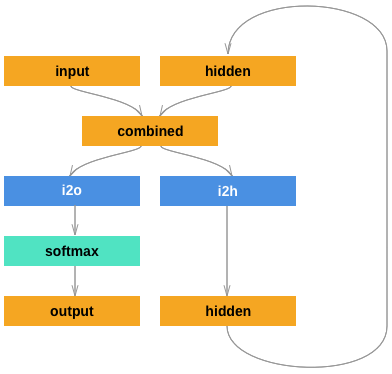

In [27]:
import torch.nn as nn

class RNN(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(RNN, self).__init__()

        self.hidden_size = hidden_size

        self.i2h = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2o = nn.Linear(input_size + hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        hidden = self.i2h(combined)
        output = self.i2o(combined)
        output = self.softmax(output)
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size, device=device)

n_hidden = 128
rnn = RNN(n_letters, n_hidden, n_categories).to(device)
print(rnn)


RNN(
  (i2h): Linear(in_features=185, out_features=128, bias=True)
  (i2o): Linear(in_features=185, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


In [28]:
class LSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(LSTM, self).__init__()

        self.hidden_size = hidden_size

        self.rnn = nn.LSTM(input_size, hidden_size)
        self.out = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=-1)

    def forward(self, input, h, c):
        out, (h, c) = self.rnn(input, (h, c))
        output = self.out(out)
        output = self.softmax(output)
        return output, h, c

    def initHidden(self):
        return (
            torch.zeros(1, 1, self.hidden_size, device=device),
            torch.zeros(1, 1, self.hidden_size, device=device),
        )

# The first experiment asks for the original RNN. Keep this class for the later
# LSTM comparison, but do not overwrite `rnn` here.
# lstm_model = LSTM(n_letters, 64, n_categories).to(device)


To run a step of this network we need to pass an input (in our case, the Tensor for the current letter) and a previous hidden state (which we initialize as zeros at first). We’ll get back the output (probability of each language) and a next hidden state (which we keep for the next step).

In [29]:
input = letterToTensor('A')
print(input.size())
hidden = rnn.initHidden()
output, next_hidden = rnn(input, hidden)
print(output.size())


torch.Size([1, 57])
torch.Size([1, 18])


For the sake of efficiency we don’t want to be creating a new Tensor for every step, so we will use lineToTensor instead of letterToTensor and use slices. This could be further optimized by pre-computing batches of Tensors.

In [30]:
input = lineToTensor('Albert')
print(input.size())
hidden = rnn.initHidden()

for i in range(input.size()[0]):
    output, hidden = rnn(input[i], hidden)

print(torch.exp(output))


torch.Size([6, 1, 57])
tensor([[0.0624, 0.0492, 0.0588, 0.0524, 0.0504, 0.0533, 0.0475, 0.0628, 0.0535,
         0.0560, 0.0661, 0.0521, 0.0557, 0.0529, 0.0581, 0.0541, 0.0583, 0.0561]],
       device='cuda:0', grad_fn=<ExpBackward0>)


As you can see the output is a <1 x n_categories> Tensor, where every item is the likelihood of that category (higher is more likely).

### Preparing for Training
Before going into training we should make a few helper functions. The first is to interpret the output of the network, which we know to be a likelihood of each category. We can use Tensor.topk to get the index of the greatest value:

In [31]:
def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

print(categoryFromOutput(output))

('Japanese', 10)


We will also want a quick way to get a training example (a name and its language):

In [32]:
import random

random.seed(0)

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def split_by_category(category_lines, validation_ratio=0.2):
    train_lines = {}
    val_lines = {}

    for category, lines in category_lines.items():
        shuffled = lines[:]
        random.shuffle(shuffled)
        n_val = max(1, int(len(shuffled) * validation_ratio))
        val_lines[category] = shuffled[:n_val]
        train_lines[category] = shuffled[n_val:]

    return train_lines, val_lines

train_category_lines, val_category_lines = split_by_category(category_lines)
val_examples = [
    (category, line)
    for category in all_categories
    for line in val_category_lines[category]
]

print('train examples =', sum(len(v) for v in train_category_lines.values()))
print('validation examples =', len(val_examples))

def randomExample(split_lines):
    category = randomChoice(all_categories)
    line = randomChoice(split_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long, device=device)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

def randomTrainingExample():
    return randomExample(train_category_lines)

for i in range(10):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    print('category =', category, '/ line =', line)


train examples = 16069
validation examples = 4005
category = Polish / line = Kava
category = Greek / line = Christodoulou
category = Arabic / line = Nassar
category = Dutch / line = Aarle
category = Greek / line = Chrysanthopoulos
category = Italian / line = Vitali
category = Czech / line = Slezak
category = Arabic / line = Koury
category = Arabic / line = Atiyeh
category = Vietnamese / line = Quach


### Training the Network
Now all it takes to train this network is show it a bunch of examples, have it make guesses, and tell it if it’s wrong.

For the loss function nn.NLLLoss is appropriate, since the last layer of the RNN is nn.LogSoftmax.

In [33]:
criterion = nn.NLLLoss()

Each loop of training will:

- Create input and target tensors
- Create a zeroed initial hidden state
- Read each letter in and keep hidden state for next letter
- Compare final output to target
- Back-propagate
- Return the output and loss

In [34]:
learning_rate = 0.005 # If you set this too high, it might explode. If too low, it might not learn

def run_rnn(line_tensor):
    hidden = rnn.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = rnn(line_tensor[i], hidden)

    return output

def train(category_tensor, line_tensor):
    rnn.zero_grad()

    output = run_rnn(line_tensor)

    loss = criterion(output, category_tensor)
    loss.backward()

    # Add parameters' gradients to their values, multiplied by learning rate
    with torch.no_grad():
        for p in rnn.parameters():
            p.add_(p.grad, alpha=-learning_rate)

    return output, loss.item()

def evaluate(line_tensor):
    with torch.no_grad():
        return run_rnn(line_tensor)

def evaluate_examples(examples):
    total_loss = 0
    correct = 0

    for category, line in examples:
        category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long, device=device)
        line_tensor = lineToTensor(line)
        output = evaluate(line_tensor)
        total_loss += criterion(output, category_tensor).item()
        guess, guess_i = categoryFromOutput(output)
        correct += int(guess == category)

    avg_loss = total_loss / len(examples)
    accuracy = correct / len(examples)
    return avg_loss, accuracy


Now we just have to run that with a bunch of examples. Since the train function returns both the output and loss we can print its guesses and also keep track of loss for plotting. Since there are 1000s of examples we print only every print_every examples, and take an average of the loss.

In [35]:
import time
import math

n_iters = 100000
print_every = 5000
plot_every = 1000

# Keep track of losses and validation accuracy for plotting
current_loss = 0
all_losses = []
val_losses = []
val_accuracies = []
plot_steps = []

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

start = time.time()
last_val_loss = None
last_val_acc = None

for iter in range(1, n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train(category_tensor, line_tensor)
    current_loss += loss

    # Add current training loss average and evaluate on the validation set
    if iter % plot_every == 0:
        all_losses.append(current_loss / plot_every)
        current_loss = 0
        last_val_loss, last_val_acc = evaluate_examples(val_examples)
        val_losses.append(last_val_loss)
        val_accuracies.append(last_val_acc)
        plot_steps.append(iter)

    # Print iter number, loss, name, guess, and validation metrics
    if iter % print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = 'correct' if guess == category else 'wrong (%s)' % category
        print('%d %d%% (%s) train_loss=%.4f val_loss=%.4f val_acc=%.2f%% %s / %s %s' % (
            iter,
            iter / n_iters * 100,
            timeSince(start),
            loss,
            last_val_loss,
            last_val_acc * 100,
            line,
            guess,
            correct,
        ))


5000 5% (0m 31s) train_loss=2.4968 val_loss=2.4092 val_acc=32.56% Pereira / Japanese wrong (Portuguese)
10000 10% (1m 5s) train_loss=3.7594 val_loss=2.1922 val_acc=38.85% Kool / Korean wrong (Dutch)
15000 15% (1m 43s) train_loss=2.4300 val_loss=2.0556 val_acc=34.71% Vicario / Portuguese wrong (Spanish)
20000 20% (3m 16s) train_loss=1.4550 val_loss=1.9614 val_acc=36.18% Cunningham / Scottish correct
25000 25% (4m 48s) train_loss=0.4621 val_loss=1.5692 val_acc=51.44% Ozawa / Japanese correct
30000 30% (6m 15s) train_loss=1.2396 val_loss=1.5461 val_acc=53.06% Kijek / Polish correct
35000 35% (7m 48s) train_loss=4.3092 val_loss=1.7020 val_acc=45.94% Martin / Irish wrong (German)
40000 40% (9m 4s) train_loss=2.1686 val_loss=1.7521 val_acc=45.47% Deniau / Irish wrong (French)
45000 45% (10m 26s) train_loss=2.1802 val_loss=1.6510 val_acc=49.04% Hanetsky / Scottish wrong (Russian)
50000 50% (11m 33s) train_loss=1.8267 val_loss=1.6695 val_acc=48.89% Fargher / Irish wrong (English)
55000 55% (12

### Plotting the Results
Plotting the historical loss from all_losses shows the network learning:

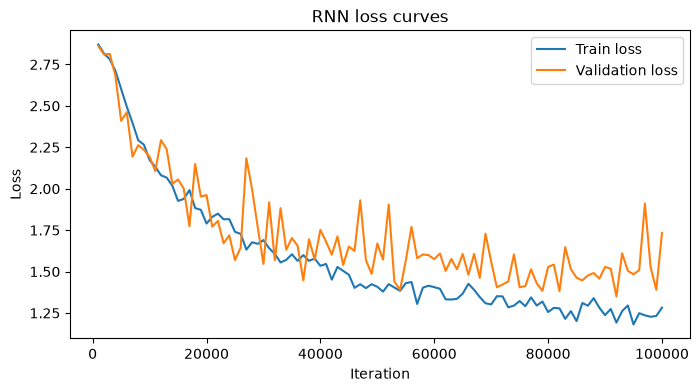

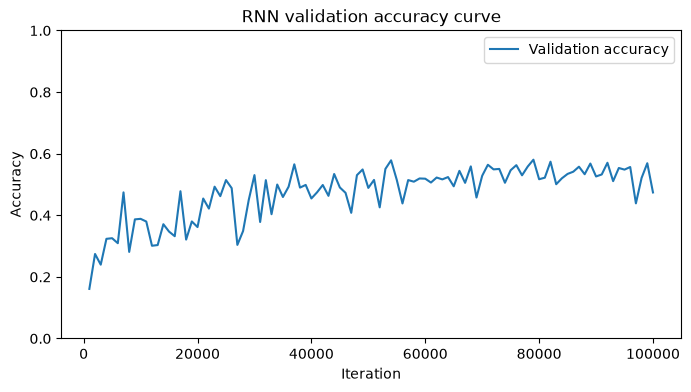

In [36]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

plt.figure(figsize=(8, 4))
plt.plot(plot_steps, all_losses, label='Train loss')
plt.plot(plot_steps, val_losses, label='Validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('RNN loss curves')
plt.legend()
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(plot_steps, val_accuracies, label='Validation accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('RNN validation accuracy curve')
plt.ylim(0, 1)
plt.legend()
plt.show()


### Evaluating the Results
To see how well the network performs on different categories, we will create a confusion matrix, indicating for every actual language (rows) which language the network guesses (columns). To calculate the confusion matrix a bunch of samples are run through the network with evaluate(), which is the same as train() minus the backprop.

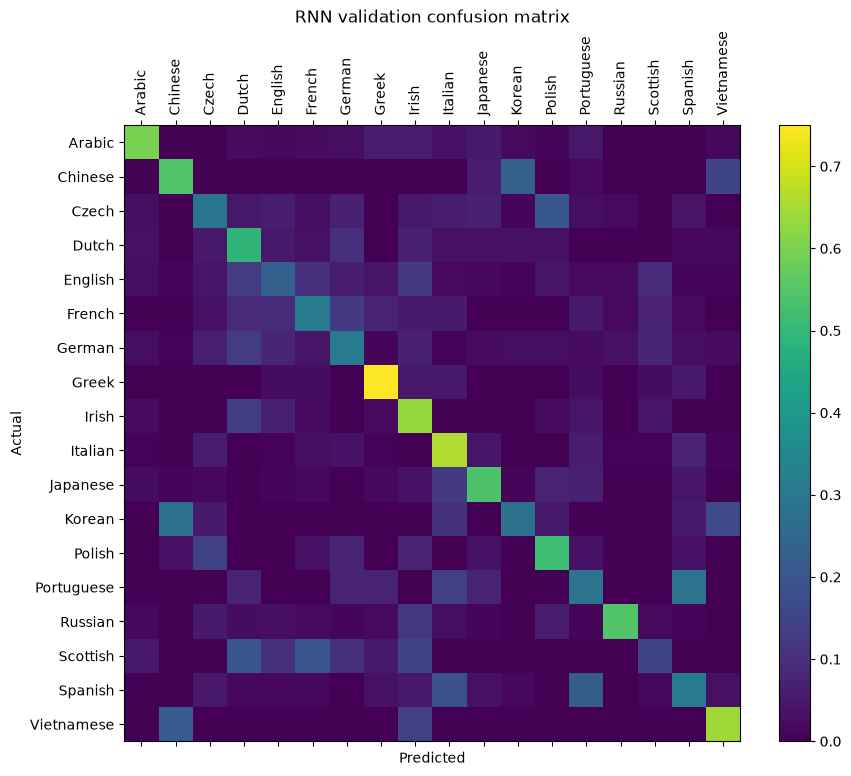

In [37]:
# Keep track of correct guesses in a validation-set confusion matrix
confusion = torch.zeros(n_categories, n_categories)

for category, line in val_examples:
    line_tensor = lineToTensor(line)
    output = evaluate(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    confusion[category_i][guess_i] += 1

# Normalize by dividing every row by its sum
for i in range(n_categories):
    row_sum = confusion[i].sum()
    if row_sum > 0:
        confusion[i] = confusion[i] / row_sum

# Set up plot
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
cax = ax.matshow(confusion.numpy())
fig.colorbar(cax)

# Set up axes
ax.set_xticks(range(n_categories))
ax.set_yticks(range(n_categories))
ax.set_xticklabels(all_categories, rotation=90)
ax.set_yticklabels(all_categories)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('RNN validation confusion matrix')

# Force label at every tick
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.show()


You can pick out bright spots off the main axis that show which languages it guesses incorrectly, e.g. Chinese for Korean, and Spanish for Italian. It seems to do very well with Greek, and very poorly with English (perhaps because of overlap with other languages).

### Save RNN Results for Comparison
Before training the LSTM, keep a copy of the original RNN model, curves, and validation confusion matrix. The LSTM will use the same validation set stored in `val_examples`.


In [38]:
rnn_model = rnn
rnn_plot_steps = plot_steps[:]
rnn_train_losses = all_losses[:]
rnn_val_losses = val_losses[:]
rnn_val_accuracies = val_accuracies[:]
rnn_confusion = confusion.detach().cpu().clone()

print('Saved RNN results:')
print('  final validation loss = %.4f' % rnn_val_losses[-1])
print('  final validation accuracy = %.2f%%' % (rnn_val_accuracies[-1] * 100))


Saved RNN results:
  final validation loss = 1.7335
  final validation accuracy = 47.42%


### Personal LSTM Network


In [39]:
class NameLSTM(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NameLSTM, self).__init__()

        self.hidden_size = hidden_size
        self.i2gates = nn.Linear(input_size + hidden_size, hidden_size * 4)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

        # A positive forget-gate bias helps the cell keep useful information
        # during the first few training iterations.
        with torch.no_grad():
            self.i2gates.bias[:hidden_size].fill_(1.0)

    def forward(self, input, hidden, cell):
        combined = torch.cat((input, hidden), 1)
        gates = self.i2gates(combined)
        forget_gate, input_gate, candidate_gate, output_gate = gates.chunk(4, dim=1)

        forget_gate = torch.sigmoid(forget_gate)
        input_gate = torch.sigmoid(input_gate)
        candidate_gate = torch.tanh(candidate_gate)
        output_gate = torch.sigmoid(output_gate)

        cell = forget_gate * cell + input_gate * candidate_gate
        hidden = output_gate * torch.tanh(cell)
        output = self.softmax(self.h2o(hidden))
        return output, hidden, cell

    def initHidden(self):
        hidden = torch.zeros(1, self.hidden_size, device=device)
        cell = torch.zeros(1, self.hidden_size, device=device)
        return hidden, cell

lstm_hidden = 128
lstm_model = NameLSTM(n_letters, lstm_hidden, n_categories).to(device)
print(lstm_model)


NameLSTM(
  (i2gates): Linear(in_features=185, out_features=512, bias=True)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


### Train the LSTM on the Same Train/Validation Split
下面的代码使用 `train_category_lines` 训练，并用同一个验证集 `val_examples` 方便对比。


In [40]:
lstm_learning_rate = 0.005

def run_lstm(line_tensor):
    hidden, cell = lstm_model.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden, cell = lstm_model(line_tensor[i], hidden, cell)

    return output

def train_lstm(category_tensor, line_tensor):
    lstm_model.zero_grad()

    output = run_lstm(line_tensor)

    loss = criterion(output, category_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(lstm_model.parameters(), 5.0)

    with torch.no_grad():
        for p in lstm_model.parameters():
            if p.grad is not None:
                p.add_(p.grad, alpha=-lstm_learning_rate)

    return output, loss.item()

def evaluate_lstm(line_tensor):
    with torch.no_grad():
        return run_lstm(line_tensor)

def evaluate_lstm_examples(examples):
    total_loss = 0
    correct = 0

    for category, line in examples:
        category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long, device=device)
        line_tensor = lineToTensor(line)
        output = evaluate_lstm(line_tensor)
        total_loss += criterion(output, category_tensor).item()
        guess, guess_i = categoryFromOutput(output)
        correct += int(guess == category)

    avg_loss = total_loss / len(examples)
    accuracy = correct / len(examples)
    return avg_loss, accuracy


In [41]:
lstm_n_iters = n_iters
lstm_print_every = print_every
lstm_plot_every = plot_every

lstm_current_loss = 0
lstm_train_losses = []
lstm_val_losses = []
lstm_val_accuracies = []
lstm_plot_steps = []

random.seed(1)
start = time.time()
last_lstm_val_loss = None
last_lstm_val_acc = None

for iter in range(1, lstm_n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train_lstm(category_tensor, line_tensor)
    lstm_current_loss += loss

    if iter % lstm_plot_every == 0:
        lstm_train_losses.append(lstm_current_loss / lstm_plot_every)
        lstm_current_loss = 0
        last_lstm_val_loss, last_lstm_val_acc = evaluate_lstm_examples(val_examples)
        lstm_val_losses.append(last_lstm_val_loss)
        lstm_val_accuracies.append(last_lstm_val_acc)
        lstm_plot_steps.append(iter)

    if iter % lstm_print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = 'correct' if guess == category else 'wrong (%s)' % category
        print('%d %d%% (%s) train_loss=%.4f val_loss=%.4f val_acc=%.2f%% %s / %s %s' % (
            iter,
            iter / lstm_n_iters * 100,
            timeSince(start),
            loss,
            last_lstm_val_loss,
            last_lstm_val_acc * 100,
            line,
            guess,
            correct,
        ))


5000 5% (0m 59s) train_loss=2.7408 val_loss=2.8272 val_acc=26.42% Bagaryatsky / Polish wrong (Russian)
10000 10% (1m 56s) train_loss=2.8152 val_loss=2.8291 val_acc=1.17% De santigo / Greek wrong (Portuguese)
15000 15% (2m 55s) train_loss=2.7881 val_loss=2.6621 val_acc=29.16% Fritsch / Italian wrong (Czech)
20000 20% (3m 52s) train_loss=2.8143 val_loss=2.5491 val_acc=14.63% Sinagra / Japanese wrong (Italian)
25000 25% (4m 54s) train_loss=2.4346 val_loss=2.5583 val_acc=12.28% Ferguson / Dutch wrong (Scottish)
30000 30% (5m 53s) train_loss=3.7606 val_loss=2.5510 val_acc=12.46% Michel / English wrong (Polish)
35000 35% (6m 53s) train_loss=2.5470 val_loss=2.2618 val_acc=30.94% Mayer / Arabic wrong (Czech)
40000 40% (7m 50s) train_loss=3.8253 val_loss=2.2092 val_acc=31.44% Ashbrook / Polish wrong (English)
45000 45% (8m 48s) train_loss=3.1408 val_loss=2.1824 val_acc=29.09% Kelly / English wrong (Irish)
50000 50% (9m 46s) train_loss=2.2761 val_loss=2.0113 val_acc=36.55% Ewing / Scottish wrong

### Plot LSTM Results


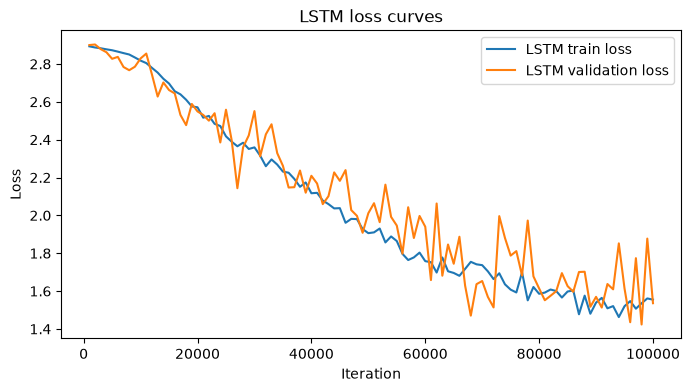

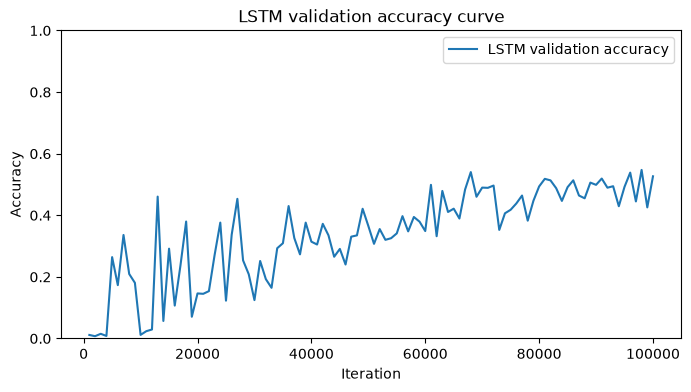

In [42]:
plt.figure(figsize=(8, 4))
plt.plot(lstm_plot_steps, lstm_train_losses, label='LSTM train loss')
plt.plot(lstm_plot_steps, lstm_val_losses, label='LSTM validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('LSTM loss curves')
plt.legend()
plt.savefig('lstm_loss_curves.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(lstm_plot_steps, lstm_val_accuracies, label='LSTM validation accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('LSTM validation accuracy curve')
plt.ylim(0, 1)
plt.legend()
plt.savefig('lstm_accuracy_curve.png', dpi=200, bbox_inches='tight')
plt.show()


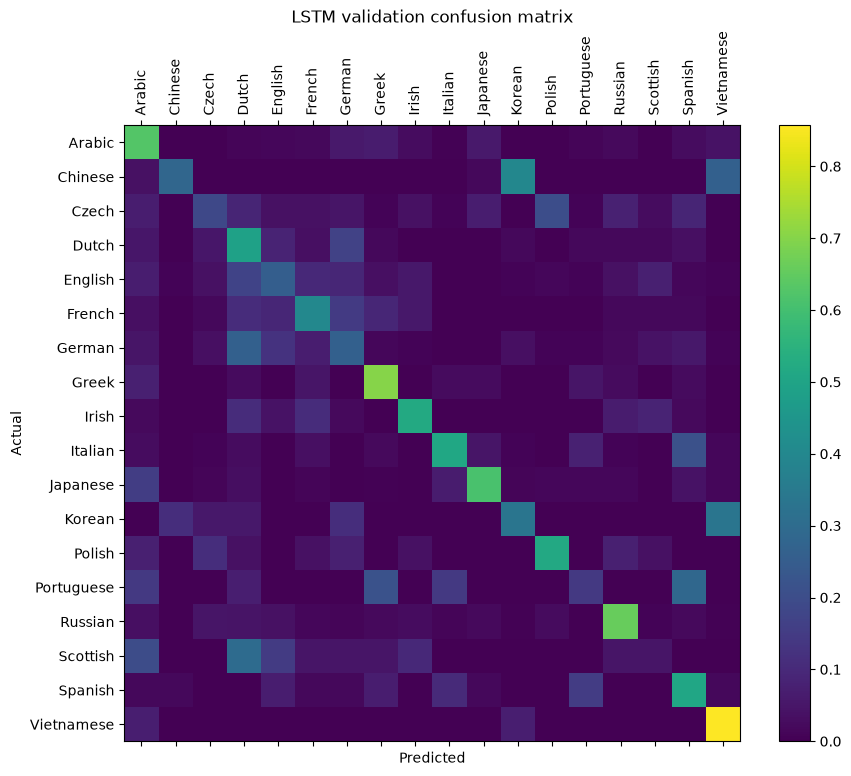

In [43]:
lstm_confusion = torch.zeros(n_categories, n_categories)

for category, line in val_examples:
    line_tensor = lineToTensor(line)
    output = evaluate_lstm(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    lstm_confusion[category_i][guess_i] += 1

for i in range(n_categories):
    row_sum = lstm_confusion[i].sum()
    if row_sum > 0:
        lstm_confusion[i] = lstm_confusion[i] / row_sum

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
cax = ax.matshow(lstm_confusion.numpy())
fig.colorbar(cax)

ax.set_xticks(range(n_categories))
ax.set_yticks(range(n_categories))
ax.set_xticklabels(all_categories, rotation=90)
ax.set_yticklabels(all_categories)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('LSTM validation confusion matrix')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.savefig('lstm_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()


### RNN vs LSTM Comparison


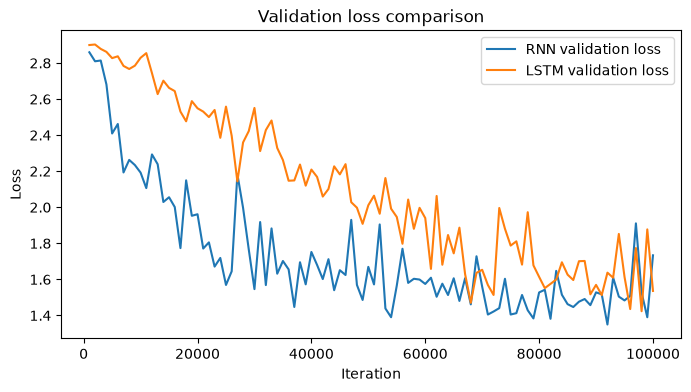

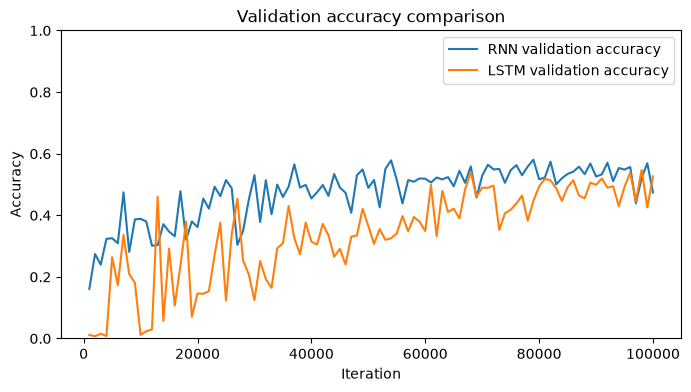

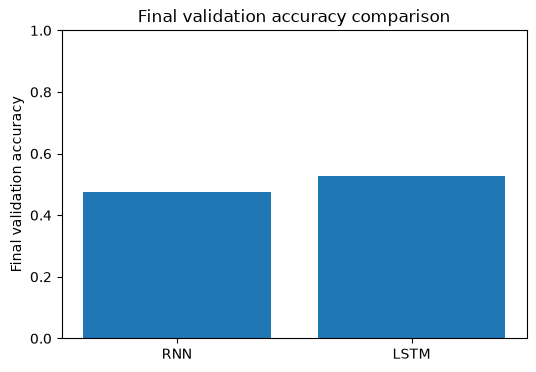

In [44]:
plt.figure(figsize=(8, 4))
plt.plot(rnn_plot_steps, rnn_val_losses, label='RNN validation loss')
plt.plot(lstm_plot_steps, lstm_val_losses, label='LSTM validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('Validation loss comparison')
plt.legend()
plt.savefig('rnn_lstm_loss_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(rnn_plot_steps, rnn_val_accuracies, label='RNN validation accuracy')
plt.plot(lstm_plot_steps, lstm_val_accuracies, label='LSTM validation accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('Validation accuracy comparison')
plt.ylim(0, 1)
plt.legend()
plt.savefig('rnn_lstm_accuracy_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(6, 4))
plt.bar(['RNN', 'LSTM'], [rnn_val_accuracies[-1], lstm_val_accuracies[-1]])
plt.ylim(0, 1)
plt.ylabel('Final validation accuracy')
plt.title('Final validation accuracy comparison')
plt.savefig('rnn_lstm_final_accuracy_comparison.png', dpi=200, bbox_inches='tight')
plt.show()


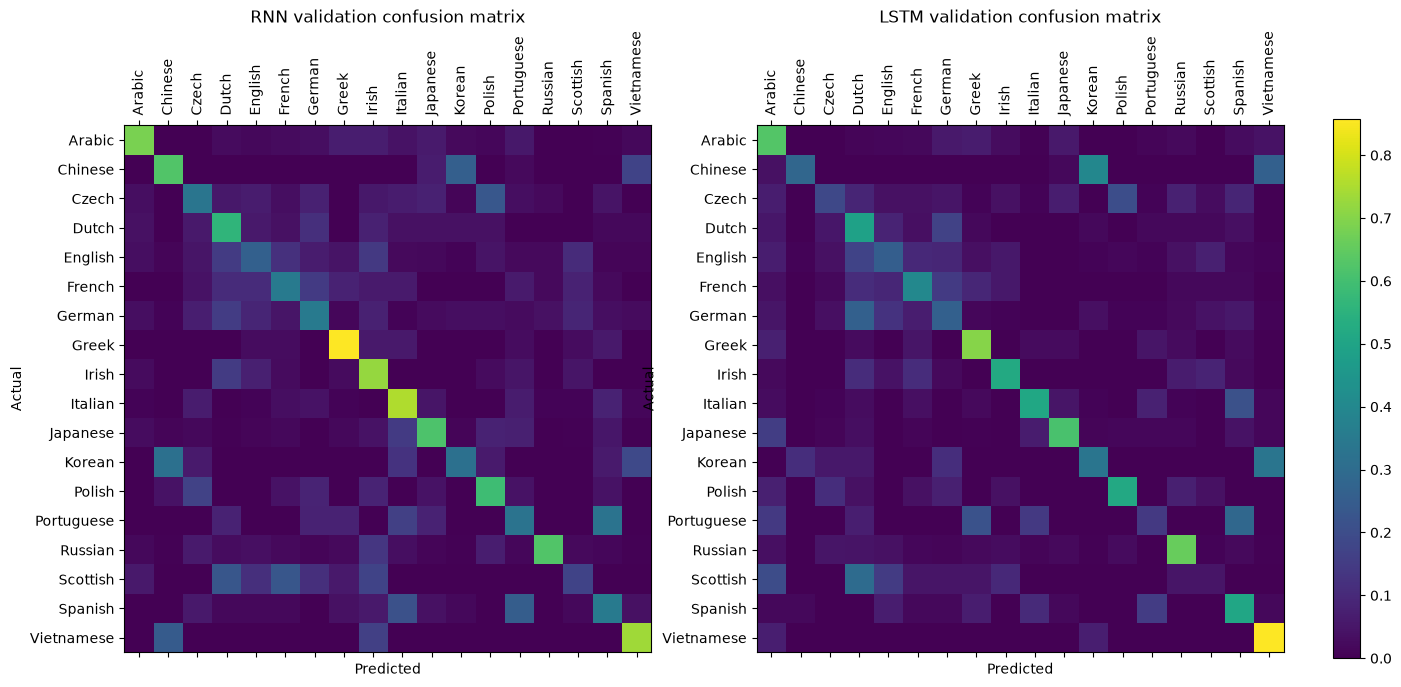

Final RNN validation accuracy: 47.42%
Final LSTM validation accuracy: 52.66%
Final RNN validation loss: 1.7335
Final LSTM validation loss: 1.5360


In [45]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, matrix, title in [
    (axes[0], rnn_confusion.numpy(), 'RNN validation confusion matrix'),
    (axes[1], lstm_confusion.numpy(), 'LSTM validation confusion matrix'),
]:
    image = ax.matshow(matrix)
    ax.set_xticks(range(n_categories))
    ax.set_yticks(range(n_categories))
    ax.set_xticklabels(all_categories, rotation=90)
    ax.set_yticklabels(all_categories)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(title)

fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.04)
plt.savefig('rnn_lstm_confusion_comparison.png', dpi=200, bbox_inches='tight')
plt.show()

print('Final RNN validation accuracy: %.2f%%' % (rnn_val_accuracies[-1] * 100))
print('Final LSTM validation accuracy: %.2f%%' % (lstm_val_accuracies[-1] * 100))
print('Final RNN validation loss: %.4f' % rnn_val_losses[-1])
print('Final LSTM validation loss: %.4f' % lstm_val_losses[-1])


### GRU Network
个人实现的GRU网络结构，在相同验证集上训练。


In [46]:
# Run this cell 用来恢复因为关闭ipynb而失效的变量。
from __future__ import unicode_literals, print_function, division
from io import open
import glob
import os
import random
import time
import math
import unicodedata
import string

import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

all_letters = string.ascii_letters + " .,;'"
n_letters = len(all_letters)

def findFiles(path):
    return glob.glob(path)

candidate_paths = ['names/*.txt', '3-循环神经网络作业/names/*.txt', 'data/names/*.txt', '../data/names/*.txt']
name_files = []
for path in candidate_paths:
    name_files = sorted(findFiles(path))
    if name_files:
        break

if not name_files:
    raise FileNotFoundError('Could not find names data. Expected names/*.txt in this folder.')

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
        and c in all_letters
    )

def readLines(filename):
    lines = open(filename, encoding='utf-8').read().strip().split('\n')
    return [unicodeToAscii(line) for line in lines]

category_lines = {}
all_categories = []
for filename in name_files:
    category = os.path.splitext(os.path.basename(filename))[0]
    all_categories.append(category)
    category_lines[category] = readLines(filename)

n_categories = len(all_categories)
print('n_categories =', n_categories)

def letterToIndex(letter):
    return all_letters.find(letter)

def letterToTensor(letter):
    tensor = torch.zeros(1, n_letters, device=device)
    tensor[0][letterToIndex(letter)] = 1
    return tensor

def lineToTensor(line):
    tensor = torch.zeros(len(line), 1, n_letters, device=device)
    for li, letter in enumerate(line):
        tensor[li][0][letterToIndex(letter)] = 1
    return tensor

def categoryFromOutput(output):
    top_n, top_i = output.topk(1)
    category_i = top_i[0].item()
    return all_categories[category_i], category_i

random.seed(0)

def randomChoice(l):
    return l[random.randint(0, len(l) - 1)]

def split_by_category(category_lines, validation_ratio=0.2):
    train_lines = {}
    val_lines = {}

    for category, lines in category_lines.items():
        shuffled = lines[:]
        random.shuffle(shuffled)
        n_val = max(1, int(len(shuffled) * validation_ratio))
        val_lines[category] = shuffled[:n_val]
        train_lines[category] = shuffled[n_val:]

    return train_lines, val_lines

train_category_lines, val_category_lines = split_by_category(category_lines)
val_examples = [
    (category, line)
    for category in all_categories
    for line in val_category_lines[category]
]

def randomExample(split_lines):
    category = randomChoice(all_categories)
    line = randomChoice(split_lines[category])
    category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long, device=device)
    line_tensor = lineToTensor(line)
    return category, line, category_tensor, line_tensor

def randomTrainingExample():
    return randomExample(train_category_lines)

criterion = nn.NLLLoss()

n_iters = 100000
print_every = 5000
plot_every = 1000

def timeSince(since):
    now = time.time()
    s = now - since
    m = math.floor(s / 60)
    s -= m * 60
    return '%dm %ds' % (m, s)

comparison_ready = all(
    name in globals()
    for name in [
        'rnn_plot_steps', 'rnn_val_losses', 'rnn_val_accuracies', 'rnn_confusion',
        'lstm_plot_steps', 'lstm_val_losses', 'lstm_val_accuracies', 'lstm_confusion',
    ]
)

print('train examples =', sum(len(v) for v in train_category_lines.values()))
print('validation examples =', len(val_examples))
print('RNN/LSTM comparison variables available:', comparison_ready)


Using device: cuda
n_categories = 18
train examples = 16069
validation examples = 4005
RNN/LSTM comparison variables available: True


In [47]:
class NameGRU(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(NameGRU, self).__init__()

        self.hidden_size = hidden_size
        self.i2z = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2r = nn.Linear(input_size + hidden_size, hidden_size)
        self.i2n = nn.Linear(input_size + hidden_size, hidden_size)
        self.h2o = nn.Linear(hidden_size, output_size)
        self.softmax = nn.LogSoftmax(dim=1)

    def forward(self, input, hidden):
        combined = torch.cat((input, hidden), 1)
        update_gate = torch.sigmoid(self.i2z(combined))
        reset_gate = torch.sigmoid(self.i2r(combined))

        reset_combined = torch.cat((input, reset_gate * hidden), 1)
        candidate_hidden = torch.tanh(self.i2n(reset_combined))
        hidden = update_gate * hidden + (1 - update_gate) * candidate_hidden

        output = self.softmax(self.h2o(hidden))
        return output, hidden

    def initHidden(self):
        return torch.zeros(1, self.hidden_size, device=device)

gru_hidden = 128
gru_model = NameGRU(n_letters, gru_hidden, n_categories).to(device)
print(gru_model)


NameGRU(
  (i2z): Linear(in_features=185, out_features=128, bias=True)
  (i2r): Linear(in_features=185, out_features=128, bias=True)
  (i2n): Linear(in_features=185, out_features=128, bias=True)
  (h2o): Linear(in_features=128, out_features=18, bias=True)
  (softmax): LogSoftmax(dim=1)
)


### Train the GRU on the Same Train/Validation Split
下面的 GRU 使用 `train_category_lines` 训练，并用同一个验证集 `val_examples` 方便对比。


In [48]:
gru_learning_rate = 0.005

def run_gru(line_tensor):
    hidden = gru_model.initHidden()

    for i in range(line_tensor.size()[0]):
        output, hidden = gru_model(line_tensor[i], hidden)

    return output

def train_gru(category_tensor, line_tensor):
    gru_model.zero_grad()

    output = run_gru(line_tensor)

    loss = criterion(output, category_tensor)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(gru_model.parameters(), 5.0)

    with torch.no_grad():
        for p in gru_model.parameters():
            if p.grad is not None:
                p.add_(p.grad, alpha=-gru_learning_rate)

    return output, loss.item()

def evaluate_gru(line_tensor):
    with torch.no_grad():
        return run_gru(line_tensor)

def evaluate_gru_examples(examples):
    total_loss = 0
    correct = 0

    for category, line in examples:
        category_tensor = torch.tensor([all_categories.index(category)], dtype=torch.long, device=device)
        line_tensor = lineToTensor(line)
        output = evaluate_gru(line_tensor)
        total_loss += criterion(output, category_tensor).item()
        guess, guess_i = categoryFromOutput(output)
        correct += int(guess == category)

    avg_loss = total_loss / len(examples)
    accuracy = correct / len(examples)
    return avg_loss, accuracy


In [49]:
gru_n_iters = n_iters
gru_print_every = print_every
gru_plot_every = plot_every

gru_current_loss = 0
gru_train_losses = []
gru_val_losses = []
gru_val_accuracies = []
gru_plot_steps = []

random.seed(2)
start = time.time()
last_gru_val_loss = None
last_gru_val_acc = None

for iter in range(1, gru_n_iters + 1):
    category, line, category_tensor, line_tensor = randomTrainingExample()
    output, loss = train_gru(category_tensor, line_tensor)
    gru_current_loss += loss

    if iter % gru_plot_every == 0:
        gru_train_losses.append(gru_current_loss / gru_plot_every)
        gru_current_loss = 0
        last_gru_val_loss, last_gru_val_acc = evaluate_gru_examples(val_examples)
        gru_val_losses.append(last_gru_val_loss)
        gru_val_accuracies.append(last_gru_val_acc)
        gru_plot_steps.append(iter)

    if iter % gru_print_every == 0:
        guess, guess_i = categoryFromOutput(output)
        correct = 'correct' if guess == category else 'wrong (%s)' % category
        print('%d %d%% (%s) train_loss=%.4f val_loss=%.4f val_acc=%.2f%% %s / %s %s' % (
            iter,
            iter / gru_n_iters * 100,
            timeSince(start),
            loss,
            last_gru_val_loss,
            last_gru_val_acc * 100,
            line,
            guess,
            correct,
        ))


5000 5% (1m 14s) train_loss=2.8216 val_loss=2.8639 val_acc=9.06% Bach / Japanese wrong (Vietnamese)
10000 10% (2m 26s) train_loss=2.6815 val_loss=2.7899 val_acc=22.20% Gasymov / Russian correct
15000 15% (3m 43s) train_loss=2.8320 val_loss=2.6069 val_acc=26.92% Kanaan / Irish wrong (Arabic)
20000 20% (4m 56s) train_loss=2.5708 val_loss=2.1650 val_acc=41.60% Amari / Italian wrong (Arabic)
25000 25% (6m 7s) train_loss=3.7323 val_loss=1.8717 val_acc=45.97% Jans / Portuguese wrong (German)
30000 30% (7m 21s) train_loss=0.4764 val_loss=1.8366 val_acc=42.12% Pakulski / Polish correct
35000 35% (8m 34s) train_loss=4.3800 val_loss=1.6929 val_acc=49.41% Miazga / Japanese wrong (Polish)
40000 40% (9m 49s) train_loss=1.1984 val_loss=1.7412 val_acc=45.84% Yi / Chinese wrong (Korean)
45000 45% (11m 2s) train_loss=1.2108 val_loss=1.6013 val_acc=47.64% Narita / Japanese correct
50000 50% (12m 14s) train_loss=3.2819 val_loss=1.5549 val_acc=50.71% Wiesner / German wrong (Czech)
55000 55% (13m 28s) trai

### Plot GRU Results


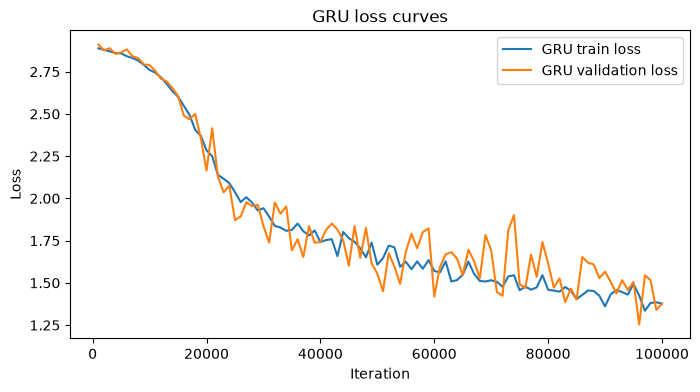

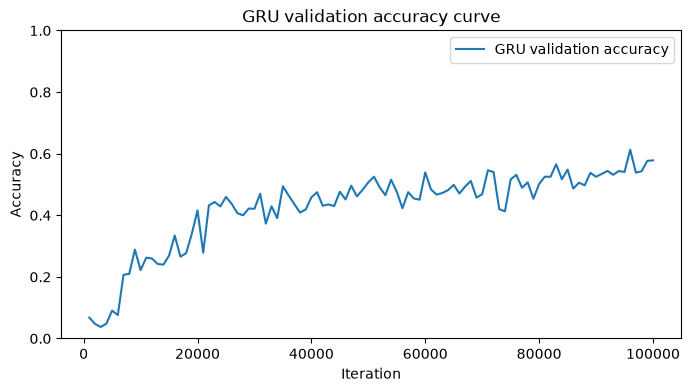

In [50]:
plt.figure(figsize=(8, 4))
plt.plot(gru_plot_steps, gru_train_losses, label='GRU train loss')
plt.plot(gru_plot_steps, gru_val_losses, label='GRU validation loss')
plt.xlabel('Iteration')
plt.ylabel('Loss')
plt.title('GRU loss curves')
plt.legend()
plt.savefig('gru_loss_curves.png', dpi=200, bbox_inches='tight')
plt.show()

plt.figure(figsize=(8, 4))
plt.plot(gru_plot_steps, gru_val_accuracies, label='GRU validation accuracy')
plt.xlabel('Iteration')
plt.ylabel('Accuracy')
plt.title('GRU validation accuracy curve')
plt.ylim(0, 1)
plt.legend()
plt.savefig('gru_accuracy_curve.png', dpi=200, bbox_inches='tight')
plt.show()


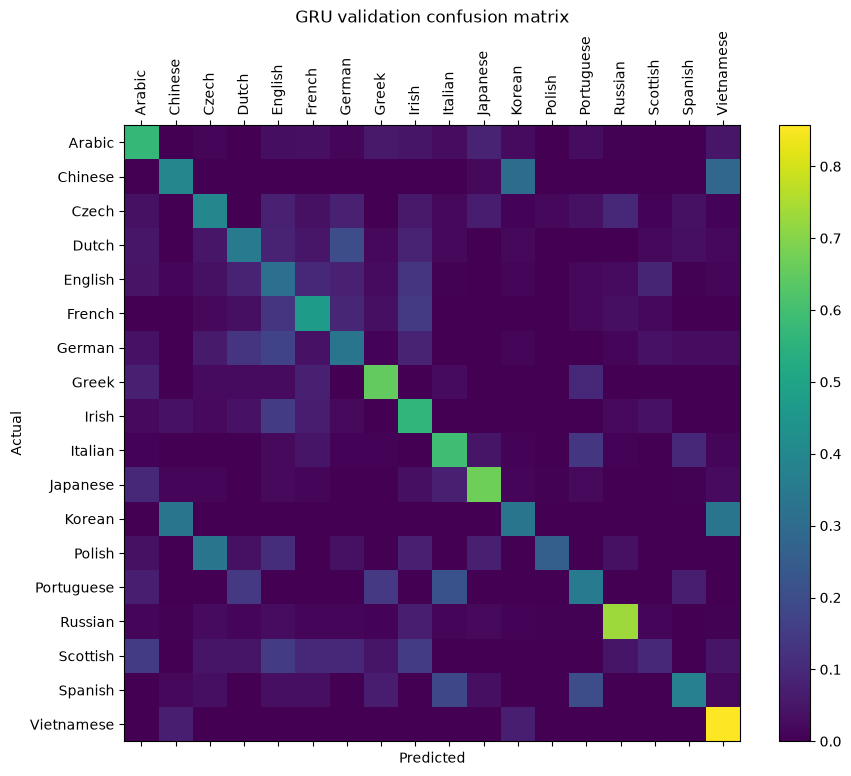

In [51]:
gru_confusion = torch.zeros(n_categories, n_categories)

for category, line in val_examples:
    line_tensor = lineToTensor(line)
    output = evaluate_gru(line_tensor)
    guess, guess_i = categoryFromOutput(output)
    category_i = all_categories.index(category)
    gru_confusion[category_i][guess_i] += 1

for i in range(n_categories):
    row_sum = gru_confusion[i].sum()
    if row_sum > 0:
        gru_confusion[i] = gru_confusion[i] / row_sum

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111)
cax = ax.matshow(gru_confusion.numpy())
fig.colorbar(cax)

ax.set_xticks(range(n_categories))
ax.set_yticks(range(n_categories))
ax.set_xticklabels(all_categories, rotation=90)
ax.set_yticklabels(all_categories)
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('GRU validation confusion matrix')
ax.xaxis.set_major_locator(ticker.MultipleLocator(1))
ax.yaxis.set_major_locator(ticker.MultipleLocator(1))

plt.savefig('gru_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()


### RNN vs LSTM vs GRU Comparison


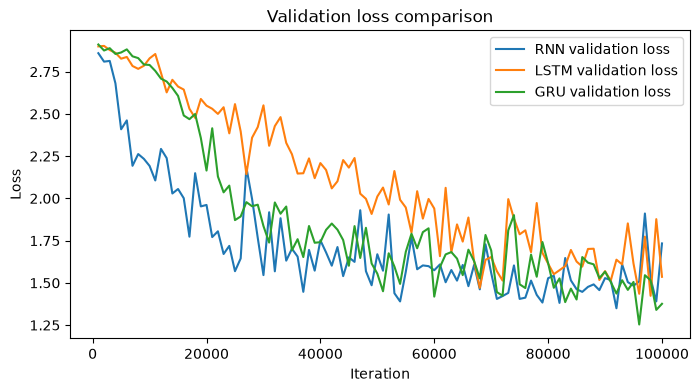

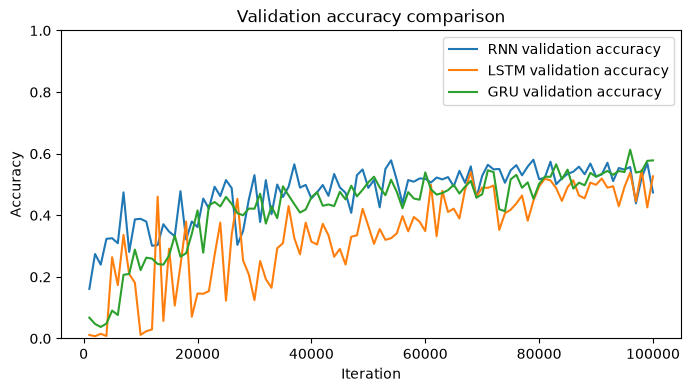

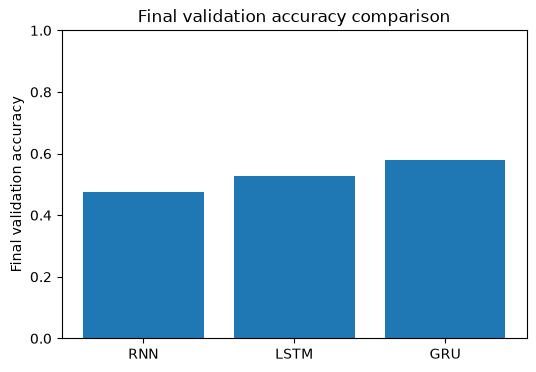

In [52]:
comparison_ready = all(
    name in globals()
    for name in [
        'rnn_plot_steps', 'rnn_val_losses', 'rnn_val_accuracies',
        'lstm_plot_steps', 'lstm_val_losses', 'lstm_val_accuracies',
    ]
)

if comparison_ready:
    plt.figure(figsize=(8, 4))
    plt.plot(rnn_plot_steps, rnn_val_losses, label='RNN validation loss')
    plt.plot(lstm_plot_steps, lstm_val_losses, label='LSTM validation loss')
    plt.plot(gru_plot_steps, gru_val_losses, label='GRU validation loss')
    plt.xlabel('Iteration')
    plt.ylabel('Loss')
    plt.title('Validation loss comparison')
    plt.legend()
    plt.savefig('rnn_lstm_gru_loss_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(rnn_plot_steps, rnn_val_accuracies, label='RNN validation accuracy')
    plt.plot(lstm_plot_steps, lstm_val_accuracies, label='LSTM validation accuracy')
    plt.plot(gru_plot_steps, gru_val_accuracies, label='GRU validation accuracy')
    plt.xlabel('Iteration')
    plt.ylabel('Accuracy')
    plt.title('Validation accuracy comparison')
    plt.ylim(0, 1)
    plt.legend()
    plt.savefig('rnn_lstm_gru_accuracy_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()

    plt.figure(figsize=(6, 4))
    plt.bar(['RNN', 'LSTM', 'GRU'], [
        rnn_val_accuracies[-1],
        lstm_val_accuracies[-1],
        gru_val_accuracies[-1],
    ])
    plt.ylim(0, 1)
    plt.ylabel('Final validation accuracy')
    plt.title('Final validation accuracy comparison')
    plt.savefig('rnn_lstm_gru_final_accuracy_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()


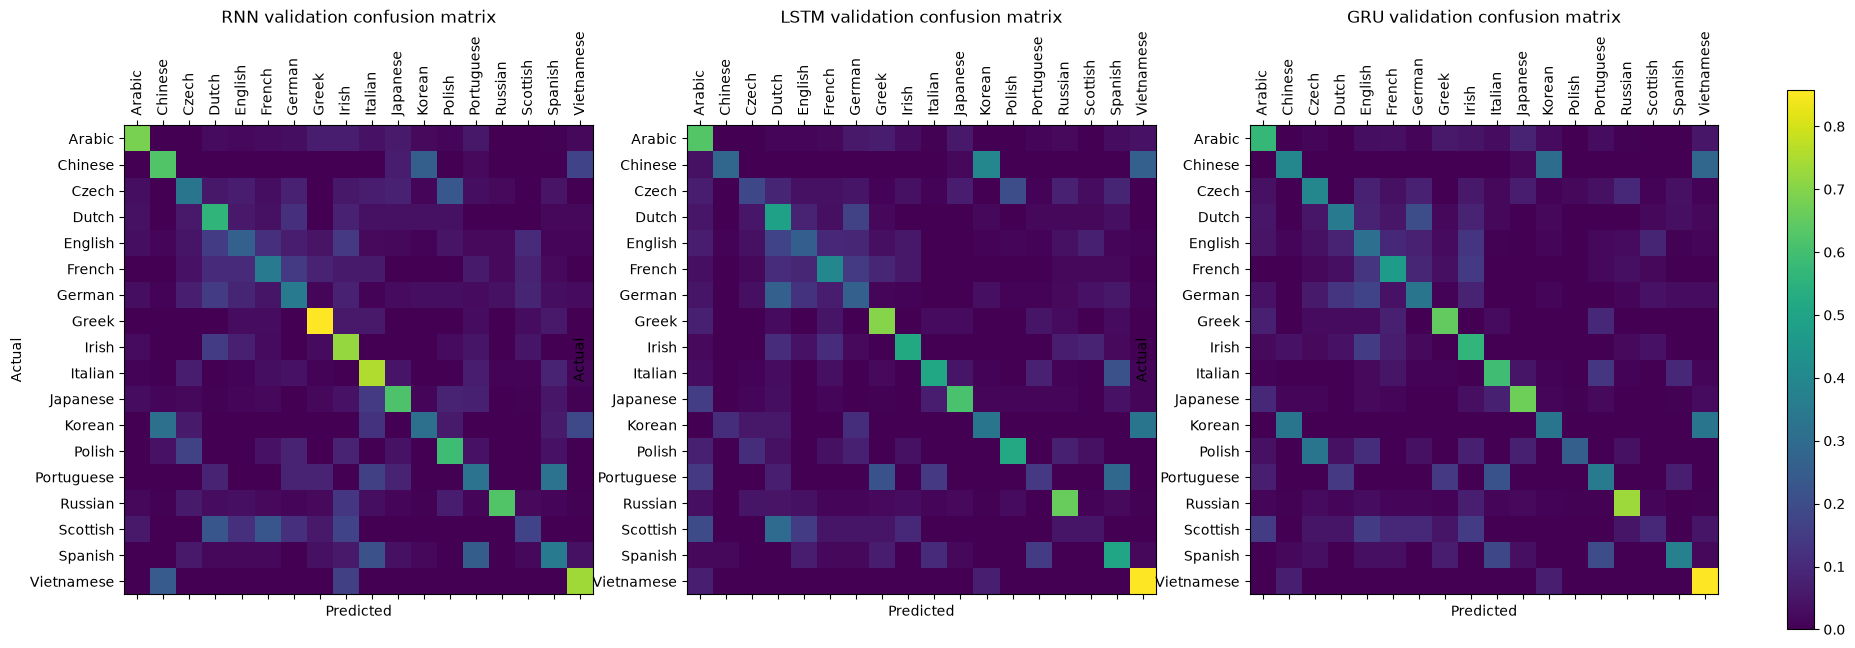

Final RNN validation accuracy: 47.42%
Final LSTM validation accuracy: 52.66%
Final GRU validation accuracy: 57.83%
Final RNN validation loss: 1.7335
Final LSTM validation loss: 1.5360
Final GRU validation loss: 1.3761


In [53]:
comparison_ready = all(
    name in globals()
    for name in ['rnn_confusion', 'lstm_confusion', 'gru_confusion']
)

if comparison_ready:
    fig, axes = plt.subplots(1, 3, figsize=(22, 7))

    for ax, matrix, title in [
        (axes[0], rnn_confusion.numpy(), 'RNN validation confusion matrix'),
        (axes[1], lstm_confusion.numpy(), 'LSTM validation confusion matrix'),
        (axes[2], gru_confusion.numpy(), 'GRU validation confusion matrix'),
    ]:
        image = ax.matshow(matrix)
        ax.set_xticks(range(n_categories))
        ax.set_yticks(range(n_categories))
        ax.set_xticklabels(all_categories, rotation=90)
        ax.set_yticklabels(all_categories)
        ax.set_xlabel('Predicted')
        ax.set_ylabel('Actual')
        ax.set_title(title)

    fig.colorbar(image, ax=axes.ravel().tolist(), fraction=0.025, pad=0.04)
    plt.savefig('rnn_lstm_gru_confusion_comparison.png', dpi=200, bbox_inches='tight')
    plt.show()

    print('Final RNN validation accuracy: %.2f%%' % (rnn_val_accuracies[-1] * 100))
    print('Final LSTM validation accuracy: %.2f%%' % (lstm_val_accuracies[-1] * 100))
    print('Final GRU validation accuracy: %.2f%%' % (gru_val_accuracies[-1] * 100))
    print('Final RNN validation loss: %.4f' % rnn_val_losses[-1])
    print('Final LSTM validation loss: %.4f' % lstm_val_losses[-1])
    print('Final GRU validation loss: %.4f' % gru_val_losses[-1])
else:
    print('RNN/LSTM confusion matrices are not available in this kernel.')
    print('Run the RNN and LSTM sections first to generate the three-model confusion-matrix comparison.')
    print('Final GRU validation accuracy: %.2f%%' % (gru_val_accuracies[-1] * 100))
    print('Final GRU validation loss: %.4f' % gru_val_losses[-1])


### Running on User Input

In [54]:
import math
import numpy as np

def predict(input_line, n_predictions=3):
    print('\n> %s' % input_line)
    with torch.no_grad():
        output = evaluate(lineToTensor(input_line))

        # Get top N categories
        topv, topi = output.topk(n_predictions, 1, True)
        predictions = []

        for i in range(n_predictions):
            value = topv[0][i].item()
            category_index = topi[0][i].item()
            print('(%.2f) %s' % (np.exp(value), all_categories[category_index]))
            predictions.append([value, all_categories[category_index]])

predict('Dovesky')
predict('Jackson')
predict('Hou')



> Dovesky
(0.57) Czech
(0.23) Russian
(0.06) English

> Jackson
(0.29) Scottish
(0.27) English
(0.14) French

> Hou
(0.54) Korean
(0.28) Chinese
(0.05) Vietnamese
